# 260901 
[machine learning chapter05, 06]

---

## 1. Today's Goal

- 배운개념 정리 및 이해
- 실습코드 플로우 이해


---

## 2. Key Concepts

#### Seq2Seq architecture
- 구글, 파파고 등 주로 번역 서비스에 활용됨
- 입력과 출력의 단어 개수가 다름 ex) 한국어 문장을 영문장으로 번역시 단어 개수가 다름
- [입력 시퀀스 -> 인코더 -> 문맥 파악 -> 디코더 -> 출력 시퀀스]
- **RNN 순환신경망 사용** 
- `encoder`: LSTM을 통해 은닉상태 h와 셀 상태 c가 순차적으로 인코더에 읽혀지면서, 입력 문장의 마지막 단어 시점에서 하나의 Context Vector로 압축됨
  (LSTM Context Vector : 마지막 은닉상태, 마지막 셀 상태)
  - LSTM에는 Sigmoid가 있어 0.5 라는 threshold를 만들어 주는데, 그 값에 따라 단기기억을 담당하는 h, 장기기억의 c로 나누어짐. -> 정보유실 방지 가능
  - Context vector는 입력 문장의 전체 맥락이 압축된 상태
  - decoder와는 달리 분류 작업이 없음
- `decoder`: Context vector를 초기 은닉 상태와 셀 상태로 설정해서 번역할 언어 단어를 한 단계씩 예측하여 생성함. 
  - decoder 최초 기동 시 특수토큰 **<sos>**가 설정되어 문장 시작을 알림, 문장 끝에는 **<eos>**
  - teacher forcing: decoder 초기에 잘못된 단어 예측하더라도, 그 다음시점 입력으로 예측값이 아닌 실제 정답 단어를 주입하여 학습 속도 안정 + 모델이 잘못 예측하는 것을 방지
  - 분류 작업: '나는' 단어 다음 어느 단어가 올지 각각 분류해서 확률을 완성하고, 가장 높은 확률의 단어를 선택함
  - 마지막에는 분류층이 추가되어 분류작업을 함

- `context vector 고정값 한계`
  - 병목현상: 입력 문장의 길이가 아무리 길어도 벡터 크기가 고정되어 있어 앞부분에 입력된 단어 정보가 점차 유실될 수 있음
  - 책 한권을 메모장 한장에 요약하는 것과 같음
  - 이를 해결하기 위해 **어텐션 메커니즘**이 등장함


#### attention mechanism
- 작동방식은 검색 엔진의 탐색 구조와 유사: 검색어 입력 Query -> 데이터베이스의 key 검색 -> 매칭되는 value값 가져옴
- 예측할 단어(내가 찾고자 하는 정보)만 집중하게 만드는 연산식으로 이해
- encoder에 있는 입력 문장의 단어를 보관해서 디코더가 언제나 참고할 수 있도록 함

- query vector: 현재 상태 벡터, "무엇을 찾을 것인가?" in decoder
- key vector: 모든 상태 벡터, "어떻게 찾을 것인가?" in encoder
- value: 모든 단어 맥락 벡터, "key를 통해 찾은 의미 정보" in encoder

- [어텐션 연산 3단계 흐름]
- 1. 유사도 측정: `query vector`, `key vector`이용해서 단어간의 유사도 점수를 구함
- 2. 가중치 분배: 유사도 점수에 소프트맥스 함수 적용하여 Attention Weight 구함 -> 총합이 1이 되는 확률 페센티지가 단어마다 분포된 형태의 가중치로 변환함
- 3. 가중합 계산: 계산된 가중치를 각 `value 벡터`에 곱한 뒤 모두 더함 -> 최종 요약 벡터 생성


#### transformer architecture
- seq2seq의 문제인 '정보 병목 현상'을 극복
- 단어를 하나씩 넣어서 처리해야 하는 RNN 한계 극복 -> 순차적 처리를 상실
- 문장 하나를 통째로 넣어버림
- 오직 attention 연산만 사용
- **병렬적** seq2seq 구조
- attention을 극대화(self-attention)한 병렬 처리 -> 맥락을 더 잘 이해함
- 현대 LLM의 모태, ChatGPT/Gemini 등...

- [embedding + 위치 encoding]
  - 모든 단어 임베딩 벡터가 한꺼번에 병렬로 모델에 주입됨
  - 모든 단어가 동시에 연산 레이어에 쏟아지므로 어떤 단어가 몇번째 자리에 왔는지에 대한 선후관계를 나타내는 **위치 임베딩** 을 기존 임베딩에 더함
  - 위치 인코딩: Sine Cosine을 이용한 계산 -> 단어간 상대적 거리 패턴을 쉽게 학습 가능, 학습 데이터에서 보지못했던 긴 문장이 들어와도 안정적인 대응 가능, 모든 위치에 대해 unique한 위치 벡터 생성 가능


- `encoder block`
- **멀티 헤드 어텐션**: 단일 셀프 어텐션 연산(self-head) 구조를 독립적으로 여러 개 묶어서 병렬화한 구조, 여러개의 평가자가 있어 여러 평가를 종합적으로 압축 -> 편향되지 않은 결과
    - `self-attention`
    - 문장 속 단어들이 다른 단어와 어떤 관계인지 스스로 점수를 매겨 파악함
    - query, key, value 사용됨 x -> query=x, key=x, value=x 
  - `밀집층`: 입력 데이터 차원(크기)를 원하는 대로 바꿈, 가중치를 통해 데이터 재가공, 특성 추출 -> 맥락을 전부 담고 있다
  - `잔차연결(residual connection)`
    - 가중치(층) 많을수록 값이 적어짐 -> 기울기 소실 -> 학습 효율 떨어지고 불안정해짐
    - 서브레이어(어텐션 등) 드롭아웃 다음에 초기입력정보가 잔차 연결됨. 이때 초기입력정보는 서브레이어를 우회
    - 층이 깊어져도 초기입력정보와 기울기가 손실 없이 원형 그대로 깊은 층까지 전달되도록 만듦
    - 최종적으로 잔차연결에서 값이 추가되어 증폭됨
  - `층 정규화`
    - 잔차연결 이후 숫자들이 증폭됨 (크기나 분포가 들쭉날쭉)
    - 단어벡터 내부 숫자 -> 평균 0, 표준편차 1로 정돈 -> 튀는 값 안정화
  - `피드 포워드 네트워크`
    - [밀집층-ReLU-밀집층-드롭아웃]
    - Linear 더블: ReLU로 선을 한번 꺾고 0이하 값 필터링 -> 모델 문맥 표현력을 높여줌(중요 특징들만 살려줌), 팽창 및 압축
      - 1번째 Linear: 좁아서 복잡한 패턴을 분리, 넓혀줌 -> 분리 및 특징 추출이 유리하도록 만듦 
      - ReLU: 넓혀진 차원에서 더 많은 뉴런을 조합 가능, 0 필터링 간ㅇ
      - 2번째 Linear: 다음 레이어로 넘겨주기 전 요약 및 메모리 절약 단계 (가공은 넓은 곳에서, 결과는 깔끔하게 압축)
- *인코더 블록 중첩 가능(입력차원=출력차원일 때)*

- `decoder block`
    -`마스크드 멀티 헤드 어텐션` tgt_mask:
      - 디코더에서 단어가 순차적으로 나와야 하므로, 학습시 뒤에 올 정답 단어를 알지 못하도록 '0'으로 가림
    - 밀집층
    - 드롭아웃
    - 잔차연결
    - 층 정규화
    - `크로스 어텐션`: query: decoder tensor 받음, key/value: encoder 출력 사용 (key,value는 맥락에 대한 정보가 담겨 있음)
    - 밀집층
    - 드롭아웃
    - 잔차연결
    - 층 정규화
    - 피드 포워드 네트워크
    - ...



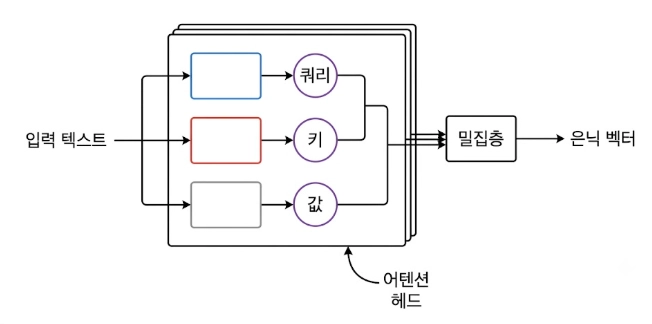

- 멀티 헤드 어텐션: 싱글헤드 구조를 여러개 묶어서 병렬화한 것

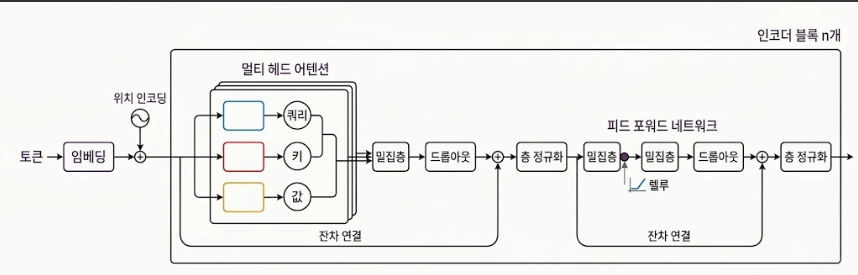

- 인코더 블록 역할

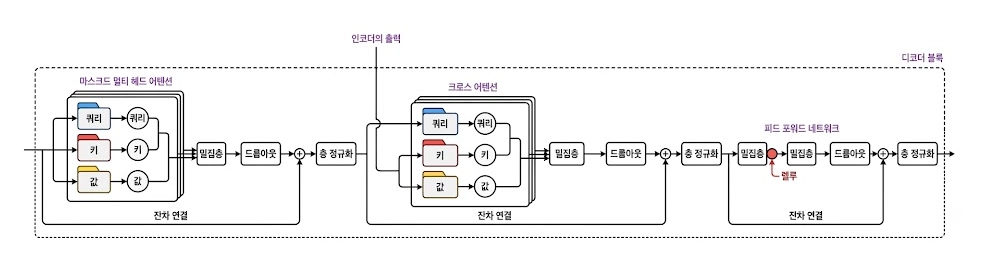
- 디코더 블록 역할

---

## 3. Practice 실습 코드

--- 
## 4. Daily Quest

> 5. 트랜스포머 디코더에서 학습 시 미래의 정답 단어를 미리 참조하지 못하도록 차단하는 기법의 이름은?
- 오답: padding masking
- 정답: causal masking

- padding masking: 의미없는 패딩 토큰을 무시
- causal masking: 미래 시점의 단어 정보를 -무한대로 적용하여 소프트맥스 확률을 0으로 만듦 ->  디코더가 다음에 올 미래 토큰을 예측 불가능하도록 만들어 컨닝 방지


헷갈린 문제
> 트랜스포머(Transformer) 아키텍처는 RNN의 순차 처리 방식을 완전히 폐기하고 병렬 연산을 도입하여 속도를 극대화했습니다. 그러나 이로 인해 상실된 '입력 단어들의 선후 관계 정보'를 모델에 다시 주입하기 위해 고안된 수학적 장치는 무엇인가요?
- 정답: positional encoding


> Seq2Seq의 병목 현상을 해결하기 위해 등장한 어텐션 메커니즘(Attention Mechanism)은 Query(Q), Key(K), Value(V)를 활용합니다. 어텐션 구조에서 디코더가 매 단어를 생성할 때 수행하는 연산 흐름으로 가장 적절한 것은 무엇인가요?
- 정답: 디코더의 현재 상태 query와 인코더의 각 단어 정보 key를 비교하여 연관성 점수를 구하고, 이를 바탕으로 인코더의 맥락 value를 가중합하여 매 시점 새로운 컨텍스트 벡터를 동적으로 생성한다.

--- 
## 5. Reflection

- mcp툴로 gpt를 연동해서 필기해보기 **기억**